In [1]:
import os
import xarray as xr
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from einops import rearrange
import sys
sys.path.insert(0, "../u-cast")
import sys
sys.path.append('../evaluation')
import indices, diagnostics
from ucast.ucast import UNetBlock, DhariwalUNet
from ucast import training import train_stage1, train_stage2

DATA_PATH = '/Bench-data'

MODELS_PATH = './models'

os.makedirs(MODELS_PATH, exist_ok=True)

domain = 'NZ'
training_experiment = 'ESD_pseudo_reality'

# Set the period
if training_experiment == 'ESD_pseudo_reality':
    period_training = '1961-1980'
elif training_experiment == 'Emulator_hist_future':
    period_training = '1961-1980_2080-2099'
else:
    raise ValueError('Provide a valid date')

# Set the GCM
if domain == 'ALPS':
    gcm_name = 'CNRM-CM5'
elif (domain == 'NZ') or (domain == 'SA'):
    gcm_name = 'ACCESS-CM2'

predictor_filename = f'.{DATA_PATH}/{domain}/{domain}_domain/train/{training_experiment}/predictors/{gcm_name}_{period_training}.nc'
predictor = xr.open_dataset(predictor_filename)

var_target = 'tasmax'

predictand_filename = f'.{DATA_PATH}/{domain}/{domain}_domain/train/{training_experiment}/target/pr_tasmax_{gcm_name}_{period_training}.nc'
predictand = xr.open_dataset(predictand_filename)
predictand = predictand[[var_target]]

if training_experiment == 'ESD_pseudo_reality':
    years_train = list(range(1961, 1975))
    years_test = list(range(1975, 1980+1))
elif training_experiment == 'Emulator_hist_fut':
    years_train = list(range(1961, 1980+1)) + list(range(2080, 2090))
    years_test = list(range(2090, 2099+1))

x_train = predictor.sel(time=np.isin(predictor['time'].dt.year, years_train))
y_train = predictand.sel(time=np.isin(predictand['time'].dt.year, years_train))

x_test = predictor.sel(time=np.isin(predictor['time'].dt.year, years_test))
y_test = predictand.sel(time=np.isin(predictand['time'].dt.year, years_test))
mean_train = x_train.mean('time')
std_train = x_train.std('time')

x_train_stand = (x_train - mean_train) / std_train
x_test_stand = (x_test - mean_train) / std_train

if domain == 'ALPS':
    spatial_dims = ('y', 'x')
elif (domain == 'NZ') or (domain == 'SA'):
    spatial_dims = ('lat', 'lon')

y_train_stack = y_train.stack(gridpoint=spatial_dims)
y_test_stack = y_test.stack(gridpoint=spatial_dims)

x_train_stand_array = torch.from_numpy(x_train_stand.to_array().transpose("time", "variable", "lat", "lon").values)
y_train_stack_array = torch.from_numpy(y_train_stack.to_array()[0, :].values)

x_test_stand_array = torch.from_numpy(x_test_stand.to_array().transpose("time", "variable", "lat", "lon").values)

class EmulationTrainingDataset(Dataset):
    def __init__(self, x_data, y_data):
        if not isinstance(x_data, torch.Tensor):
            x_data = torch.tensor(x_data)
        if not isinstance(y_data, torch.Tensor):
            y_data = torch.tensor(y_data)
        self.x_data, self.y_data = x_data, y_data

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        x_sample, y_sample = self.x_data[idx, :], self.y_data[idx, :]
        return x_sample, y_sample

class EmulationTestDataset(Dataset):
    def __init__(self, x_data):
        if not isinstance(x_data, torch.Tensor):
            x_data = torch.tensor(x_data)
        self.x_data = x_data

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        return self.x_data[idx, :]

# Make and train model (Ucast)
model = DhariwalUNet(in_channels=15, out_channels=1)

from evaluate import evaluate_model
rmse, bias_mean,bias_p98 = evaluate_model(model=model, dataset=x_test_stand_array, test_stack=y_test_stack, y_test=y_test, state_path="./models/ucast_downscale_stage2.pt", var_target="tasmax", domain=domain)

Directory 'results' created successfully.


NameError: name 'spatial_bias_mean' is not defined

In [1]:
print("hello")

hello


In [3]:
DATA_PATH = '/Bench-data'

MODELS_PATH = './models'

os.makedirs(MODELS_PATH, exist_ok=True)



In [4]:
domain = 'NZ'
training_experiment = 'ESD_pseudo_reality'

In [5]:
# Set the period
if training_experiment == 'ESD_pseudo_reality':
    period_training = '1961-1980'
elif training_experiment == 'Emulator_hist_future':
    period_training = '1961-1980_2080-2099'
else:
    raise ValueError('Provide a valid date')

# Set the GCM
if domain == 'ALPS':
    gcm_name = 'CNRM-CM5'
elif (domain == 'NZ') or (domain == 'SA'):
    gcm_name = 'ACCESS-CM2'


In [6]:
predictor_filename = f'.{DATA_PATH}/{domain}/{domain}_domain/train/{training_experiment}/predictors/{gcm_name}_{period_training}.nc'
predictor = xr.open_dataset(predictor_filename)

In [7]:
var_target = 'tasmax'

predictand_filename = f'.{DATA_PATH}/{domain}/{domain}_domain/train/{training_experiment}/target/pr_tasmax_{gcm_name}_{period_training}.nc'
predictand = xr.open_dataset(predictand_filename)
predictand = predictand[[var_target]]

In [9]:
if training_experiment == 'ESD_pseudo_reality':
    years_train = list(range(1961, 1975))
    years_test = list(range(1975, 1980+1))
elif training_experiment == 'Emulator_hist_fut':
    years_train = list(range(1961, 1980+1)) + list(range(2080, 2090))
    years_test = list(range(2090, 2099+1))

x_train = predictor.sel(time=np.isin(predictor['time'].dt.year, years_train))
y_train = predictand.sel(time=np.isin(predictand['time'].dt.year, years_train))

x_test = predictor.sel(time=np.isin(predictor['time'].dt.year, years_test))
y_test = predictand.sel(time=np.isin(predictand['time'].dt.year, years_test))

In [10]:
mean_train = x_train.mean('time')
std_train = x_train.std('time')

x_train_stand = (x_train - mean_train) / std_train
x_test_stand = (x_test - mean_train) / std_train

In [11]:
mean_train = x_train.mean('time')
std_train = x_train.std('time')

x_train_stand = (x_train - mean_train) / std_train
x_test_stand = (x_test - mean_train) / std_train

if domain == 'ALPS':
    spatial_dims = ('y', 'x')
elif (domain == 'NZ') or (domain == 'SA'):
    spatial_dims = ('lat', 'lon')

y_train_stack = y_train.stack(gridpoint=spatial_dims)
y_test_stack = y_test.stack(gridpoint=spatial_dims)

x_train_stand_array = torch.from_numpy(x_train_stand.to_array().transpose("time", "variable", "lat", "lon").values)
y_train_stack_array = torch.from_numpy(y_train_stack.to_array()[0, :].values)

x_test_stand_array = torch.from_numpy(x_test_stand.to_array().transpose("time", "variable", "lat", "lon").values)
print(x_test_stand_array[0])

In [12]:
x_train_stand_array = torch.from_numpy(x_train_stand.to_array().transpose("time", "variable", "lat", "lon").values)
y_train_stack_array = torch.from_numpy(y_train_stack.to_array()[0, :].values)

x_test_stand_array = torch.from_numpy(x_test_stand.to_array().transpose("time", "variable", "lat", "lon").values)
print(x_test_stand_array[0])

tensor([[[-0.6653, -0.6907, -0.6654,  ..., -1.4025, -1.5926, -1.5789],
         [-0.6727, -0.7344, -0.7461,  ..., -0.6459, -0.7512, -0.4798],
         [-0.6754, -0.6567, -0.6525,  ..., -0.1391,  0.2406,  0.4073],
         ...,
         [ 0.0881,  0.3596,  0.3773,  ...,  1.2685,  1.0376,  0.8076],
         [-0.2778,  0.0592,  0.3278,  ...,  0.8260,  1.0075,  1.0059],
         [-0.6205, -0.3689, -0.0573,  ...,  0.7895,  0.3732,  0.4419]],

        [[-0.7911, -0.6262, -0.6120,  ..., -1.5835, -1.6788, -1.6397],
         [-0.5619, -0.6643, -0.7813,  ..., -1.1028, -1.1471, -0.8718],
         [-0.3508, -0.4920, -0.5726,  ..., -0.5406, -0.2138,  0.0526],
         ...,
         [-0.2051, -0.0438,  0.1797,  ...,  0.9418,  0.9936,  0.9678],
         [-0.4481, -0.1542,  0.0403,  ...,  0.5637,  0.5325,  0.4123],
         [-0.4695, -0.4910, -0.3156,  ...,  0.2240,  0.1759,  0.0775]],

        [[-0.3090, -0.3672, -0.5637,  ..., -1.7471, -1.6499, -1.6330],
         [-0.3333, -0.2016, -0.2325,  ..., -1

In [13]:
class EmulationTrainingDataset(Dataset):
    def __init__(self, x_data, y_data):
        if not isinstance(x_data, torch.Tensor):
            x_data = torch.tensor(x_data)
        if not isinstance(y_data, torch.Tensor):
            y_data = torch.tensor(y_data)
        self.x_data, self.y_data = x_data, y_data

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        x_sample, y_sample = self.x_data[idx, :], self.y_data[idx, :]
        return x_sample, y_sample

class EmulationTestDataset(Dataset):
    def __init__(self, x_data):
        if not isinstance(x_data, torch.Tensor):
            x_data = torch.tensor(x_data)
        self.x_data = x_data

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        return self.x_data[idx, :]

In [14]:
dataset_training = EmulationTrainingDataset(x_data=x_train_stand_array, y_data=y_train_stack_array)
dataloader_train = DataLoader(dataset=dataset_training,
                              batch_size=32, shuffle=True)

dataset_test = EmulationTestDataset(x_data=x_test_stand_array)





In [15]:
print(dataset_training.x_data.shape)

torch.Size([5110, 15, 16, 16])


In [25]:
class DeepESD(torch.nn.Module):

    def __init__(self, x_shape: tuple, y_shape: tuple,
                 filters_last_conv: int):

        super(DeepESD, self).__init__()

        self.x_shape = x_shape
        self.y_shape = y_shape
        self.filters_last_conv = filters_last_conv

        self.conv_1 = torch.nn.Conv2d(in_channels=self.x_shape[1],
                                      out_channels=50,
                                      kernel_size=3,
                                      padding=1)

        self.conv_2 = torch.nn.Conv2d(in_channels=50,
                                      out_channels=25,
                                      kernel_size=3,
                                      padding=1)

        self.conv_3 = torch.nn.Conv2d(in_channels=25,
                                      out_channels=self.filters_last_conv,
                                      kernel_size=3,
                                      padding=1)

        self.out = torch.nn.Linear(in_features=\
                                       self.x_shape[2] * self.x_shape[3] * self.filters_last_conv,
                                       out_features=self.y_shape[1])

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        x = self.conv_1(x)
        x = torch.relu(x)

        x = self.conv_2(x)
        x = torch.relu(x)

        x = self.conv_3(x)
        x = torch.relu(x)

        x = torch.flatten(x, start_dim=1)

        out = self.out(x)

        return out

In [16]:
#Ucast
from ucast.ucast import UNetBlock, DhariwalUNet
from ucast.training import train_stage1, train_stage2

model = DhariwalUNet(in_channels=15, out_channels=1)

In [20]:

#print(model)

device = ('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
ckpt_dir = "./models"

print("hi")
final_stage1_ckpt = train_stage1(
    model, dataloader_train, dataset_training, device,
    lat_weights=None, ckpt_dir=ckpt_dir
)
    
train_stage2(
    model, dataloader_train, dataset_training, device,
    stage1_ckpt_path=final_stage1_ckpt, lat_weights=None,
    ckpt_dir=ckpt_dir
)


hi
Y_MEAN=287.8038, Y_STD=3.8896
[Stage 1] Epoch 1/5 - Loss: 0.484888
[Stage 1] Epoch 2/5 - Loss: 0.264174
[Stage 1] Epoch 3/5 - Loss: 0.209574
[Stage 1] Epoch 4/5 - Loss: 0.174940
[Stage 1] Epoch 5/5 - Loss: 0.158927
[Stage 2] Epoch 1/8 (of 12 configured) - CRPS Loss: 0.106371
[Stage 2] Epoch 2/8 (of 12 configured) - CRPS Loss: 0.094626
[Stage 2] Epoch 3/8 (of 12 configured) - CRPS Loss: 0.091090
[Stage 2] Epoch 4/8 (of 12 configured) - CRPS Loss: 0.094912
[Stage 2] Epoch 5/8 (of 12 configured) - CRPS Loss: 0.097656
[Stage 2] Epoch 6/8 (of 12 configured) - CRPS Loss: 0.098604
[Stage 2] Epoch 7/8 (of 12 configured) - CRPS Loss: 0.099129
[Stage 2] Epoch 8/8 (of 12 configured) - CRPS Loss: 0.098837


'./models/ucast_downscale_stage2.pt'

In [26]:
model = DeepESD(x_shape=x_train_stand_array.shape,
                y_shape=y_train_stack_array.shape,
                filters_last_conv=1)
print(model)

DeepESD(
  (conv_1): Conv2d(15, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_2): Conv2d(50, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_3): Conv2d(25, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (out): Linear(in_features=256, out_features=16384, bias=True)
)


In [16]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

is_ucast_model = False
ckpt_dir = "./models"

if is_ucast_model:
    
    final_stage1_ckpt = train_stage1(
        model, dataloader_train, dataset_training, device,
        lat_weights=None, ckpt_dir=ckpt_dir
    )
    
    train_stage2(
        model, dataloader_train, dataset_training, device,
        stage1_ckpt_path=final_stage1_ckpt, lat_weights=None,
        ckpt_dir=ckpt_dir
    )

else:
    model_name = f'DeepESD_U-Cast_{training_experiment}_{domain}_{var_target}.pt'
    loss_function = nn.MSELoss()
    learning_rate = 0.0001
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    num_epochs = 500
    loss_train = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for idx, (batch_x_data, batch_y_data) in enumerate(dataloader_train):
            batch_size = batch_x_data.shape[0]
            batch_x_data = batch_x_data.to(device)
            batch_y_data = batch_y_data.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x_data)
            outputs = outputs.view(batch_x_data.size(0), -1)

            loss_batch = loss_function(outputs, batch_y_data)
            epoch_loss += batch_size * loss_batch.item()

            loss_batch.backward()
            optimizer.step()

        epoch_loss = epoch_loss / len(dataset_training)
        loss_train.append(epoch_loss)
        #print(f'Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.6f}')
        torch.save(model.state_dict(), f'{ckpt_dir}/{model_name}')

KeyboardInterrupt: 

In [29]:
from ucast.utils import enable_inference_dropout 

dataset_test = EmulationTestDataset(x_data=x_test_stand_array)
test_dataloader = DataLoader(dataset=dataset_test,
                             batch_size=32, shuffle=False)

is_ucast_model = False

if is_ucast_model:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
    ckpt_path = "./models/ucast_downscale_stage2.pt"  # your Stage 2 checkpoint
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

    state_dict = ckpt["ema"] if "ema" in ckpt else ckpt["model"]
    model.load_state_dict(state_dict)
    model = model.to(device)   

    Y_MEAN = ckpt["y_mean"]
    Y_STD = ckpt["y_std"]

    model.eval()
    enable_inference_dropout(model)  # re-enable dropout for MC-ensembling, even after eval()

    N_ENSEMBLE_MEMBERS = 10  # matches typical practice in related CORDEX-ML-Bench work

    all_member_predictions = []  # will hold N_ENSEMBLE_MEMBERS arrays, each (n_samples, C, 128, 128)

    with torch.no_grad():
        for member_idx in range(N_ENSEMBLE_MEMBERS):
            member_predictions = []
            for batch_x in test_dataloader:
                batch_x = batch_x.to(next(model.parameters()).device)
                with torch.amp.autocast('cuda'):
                    outputs = model(batch_x)  # (B, C, 128, 128), normalized scale
                outputs_denormed = outputs.float() * Y_STD + Y_MEAN  # back to real physical units
                member_predictions.append(outputs_denormed.cpu().numpy())
            member_predictions = np.concatenate(member_predictions, axis=0)  # (n_samples, C, 128, 128)
            all_member_predictions.append(member_predictions)

    all_member_predictions = np.stack(all_member_predictions, axis=0)  # (N_ENSEMBLE_MEMBERS, n_samples, C, 128, 128)

    # Ensemble mean — your best single-point estimate, comparable to the deterministic models' output
    predictions = all_member_predictions.mean(axis=0)  # (n_samples, C, 128, 128)

    predictions = predictions.reshape(predictions.shape[0], -1)

else:
    state_dict = torch.load("./models/DeepESD_U-Cast_ESD_pseudo_reality_NZ_tasmax.pt", weights_only=False)
    model.load_state_dict(state_dict)
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch_x in test_dataloader:
            batch_x = batch_x.to(next(model.parameters()).device)
            outputs = model(batch_x)
            predictions.append(outputs.cpu().numpy())
    predictions = np.concatenate(predictions, axis=0)
    predictions = predictions.reshape(predictions.shape[0], -1)

y_pred_stack = y_test_stack.copy(deep=True)
y_pred_stack[var_target].values = predictions
y_pred = y_pred_stack.unstack()

In [16]:
print(next(model.parameters()).device)  # should now print cuda:0 (or similar)

cpu


In [19]:
rmse = diagnostics.rmse(x0=y_test, x1=y_pred,
                        var=var_target, dim='time')
print(f'Mean RMSE: {rmse[var_target].mean().values.item()}')
                    rmse[var_target].mean().values().item()

plot_data_map(data=rmse, var_name=var_target, domain=domain, vmin=0, vmax=5,
              fig_title='RMSE', cmap='Reds')

NameError: name 'y_pred' is not defined

In [18]:
from evaluate import evaluate_model
rmse, bias_mean, spatial_bias_mean, bias_p98 = evaluate_model(model=model, dataset=x_test_stand_array, test_stack=y_test_stack, y_test=y_test, state_path="./models/ucast_downscale_stage2.pt", var_target="tasmax", domain=domain)

Directory 'results' created successfully.


/opt/miniconda3/envs/CORDEX-ML-Bench/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/miniconda3/envs/CORDEX-ML-Bench/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


In [20]:
print(bias_mean.shape)


(128, 128)


In [25]:
print(rmse["tasmax"].values.shape)

(128, 128)


Mean Bias Mean: -0.07973632961511612


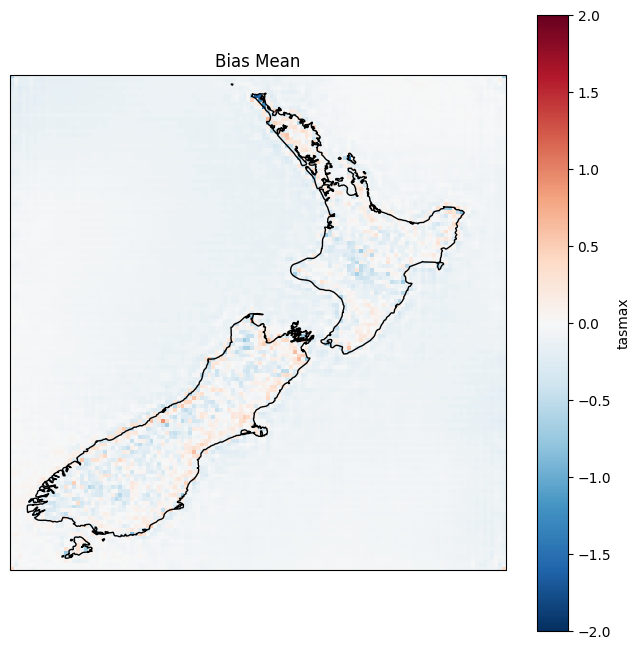

In [83]:
bias_mean = diagnostics.bias_index(x0=y_test, x1=y_pred,
                                   index_fn=indices.mean,
                                   var=var_target)
print(f'Mean Bias Mean: {bias_mean[var_target].mean().values.item()}')

plot_data_map(data=bias_mean, var_name=var_target, domain=domain, vmin=-2, vmax=2,
              fig_title='Bias Mean', cmap='RdBu_r')

Mean Bias 98th percentile: -0.4233302171155804


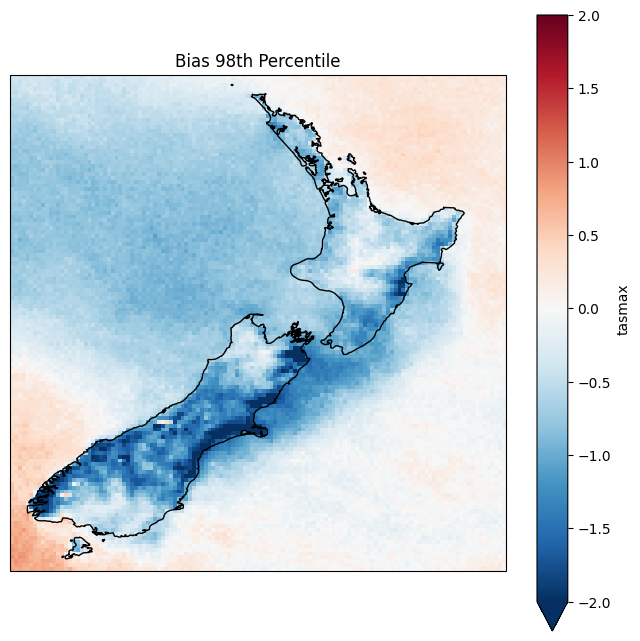

In [31]:
bias_p98 = diagnostics.bias_index(x0=y_test, x1=y_pred,
                                  index_fn=indices.quantile,
                                  q=0.98,
                                  var=var_target)
print(f'Mean Bias 98th percentile: {bias_p98[var_target].mean().values.item()}')

plot_data_map(data=bias_p98, var_name=var_target, domain=domain, vmin=-2, vmax=2,
              fig_title='Bias 98th Percentile', cmap='RdBu_r')

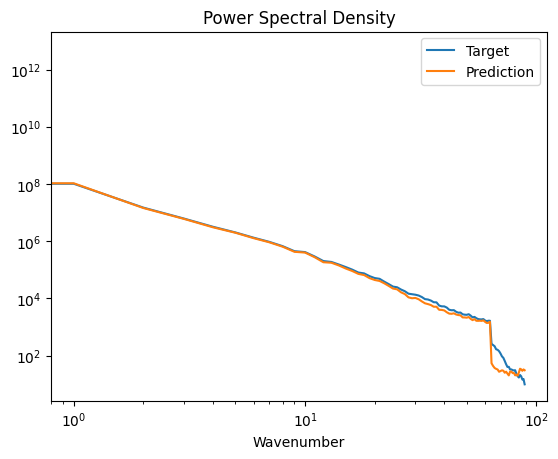

In [49]:
psd_target, psd_pred = diagnostics.psd(x0=y_test, x1=y_pred,
                                       var=var_target)
plot_psd(psd_target=psd_target, psd_pred=psd_pred)

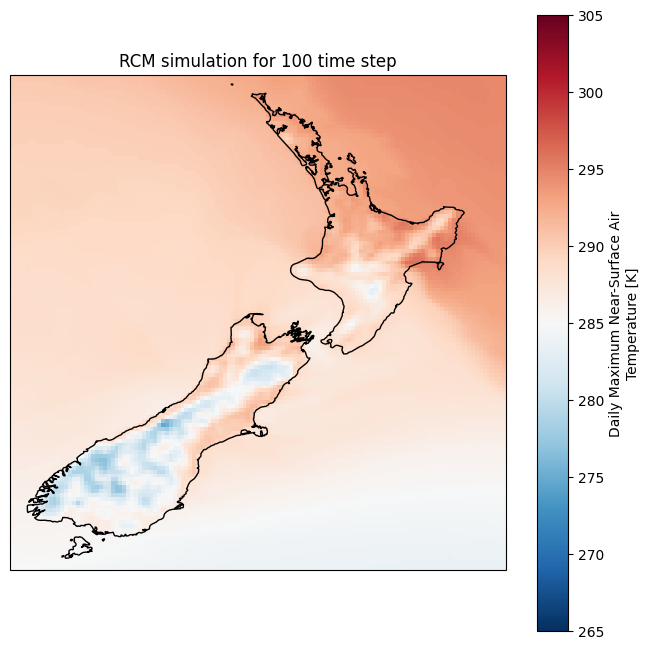

In [50]:
plot_data_map(data=y_test.isel(time=100), var_name=var_target, domain=domain,
              vmin=265, vmax=305,
              fig_title=f'RCM simulation for {100} time step', figsize=(8,8), cmap='RdBu_r')

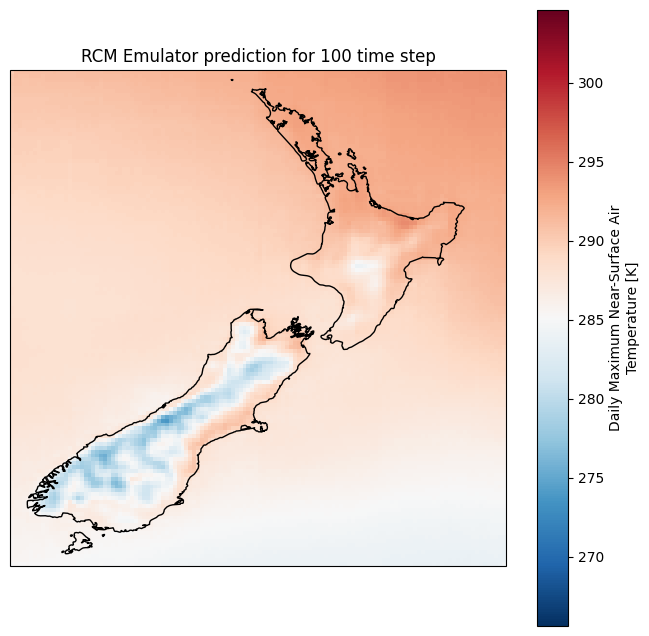

In [51]:
plot_data_map(data=y_pred.isel(time=100), var_name=var_target, domain=domain,
              vmin=y_pred[var_target].min().item(), vmax=y_pred[var_target].max().item(),
              fig_title=f'RCM Emulator prediction for {100} time step', figsize=(8,8), cmap='RdBu_r')